# Laboratorio 7 - EEG

Importar y parámetros

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, find_peaks, iirnotch
from scipy.stats import ttest_rel
from scipy.integrate import trapezoid
import os, warnings
warnings.filterwarnings("ignore")

FS      = 1000
VCC     = 3.3
ADC_RES = 1024
GAIN    = 40_000

BANDS = {
    "Delta": (0.5,  4),
    "Theta": (4,    8),
    "Alpha": (8,   13),
    "Beta":  (13,  30),
    "Gamma": (30,  48),
}
BAND_COLORS = {
    "Delta": "#CCEEFF",
    "Theta": "#CCFFDD",
    "Alpha": "#FFF5CC",
    "Beta":  "#FFD6D6",
    "Gamma": "#E8D6FF",
}

ARCHIVOS = {
    "1_Primer_Ritmo_Basal":               "Basal 1",
    "2_Mirada-Fija-En-Un-Punto":          "Mirada Fija",
    "3_Segundo-Ritmo-Basal":              "Basal 2",
    "4_Parpadeo_Y_Masticación_Constante": "Parpadeo + Masc.",
    "5_Tercer-Ritmo-Basal":               "Basal 3",
    "6-1_Música-Relajante":               "Música Relajante",
    "6-2_Música-Estresante":              "Música Estresante",
}

print("Parámetros listos.")

Parámetros listos.


Funciones

In [22]:
def leer_canal(nombre_base, col_nombre):
    """
    Lee el archivo .txt de BITalino y devuelve la señal EEG en µV.
    col_nombre: "A1" (Fp1) o "A2" (Fp2).
    Columnas del archivo: nSeq I1 I2 O1 O2 A1 A2
    Se lee por nombre para evitar errores de índice.
    """
    path = f"{nombre_base}.txt"
    if not os.path.exists(path):
        raise FileNotFoundError(f"No se encontró '{path}'. Súbelo a Colab.")

    nombres_col = ["nSeq", "I1", "I2", "O1", "O2", "A1", "A2", "extra"]
    df  = pd.read_csv(path, sep="\t", comment="#", header=None,
                      names=nombres_col, usecols=["A1", "A2"])
    adc = df[col_nombre].values.astype(float)
    adc = adc[np.isfinite(adc)]

    # Conversión ADC → µV  (fórmula BITalino EEG datasheet)
    eeg  = ((adc / ADC_RES - 0.5) * VCC) / GAIN * 1e6
    eeg -= np.median(eeg)
    return eeg


def filtrar(sig, lowcut=0.8, highcut=48, f_notch=60):
    """Pasabanda 0.8–48 Hz + notch 60 Hz + eliminación de deriva lineal."""
    nyq  = 0.5 * FS
    b, a = butter(4, [lowcut / nyq, highcut / nyq], btype="band")
    sig  = filtfilt(b, a, sig)
    b, a = iirnotch(w0=f_notch / (FS / 2), Q=30)
    sig  = filtfilt(b, a, sig)
    x    = np.arange(len(sig))
    sig -= np.polyval(np.polyfit(x, sig, 1), x)
    return sig


def psd_welch(sig):
    """PSD Welch con ventana de 2 s y 50% de solapamiento."""
    nperseg = 2 * FS
    f, p = welch(sig, fs=FS, nperseg=nperseg, noverlap=nperseg // 2,
                 window="hann", detrend="constant", scaling="density")
    return f, p


def potencia_banda(f, p, banda):
    lo, hi = banda
    m = (f >= lo) & (f <= hi)
    return trapezoid(p[m], f[m])


def potencias_relativas(f, p):
    total = potencia_banda(f, p, (0.5, 48))
    if total == 0:
        return {b: np.nan for b in BANDS}
    return {b: potencia_banda(f, p, rng) / total for b, rng in BANDS.items()}


def epoch_banda(sig, banda_key, epoch_s=2.0):
    """
    Divide la señal en epochs de epoch_s s sin solapamiento.
    Rechaza epochs cuyo RMS supere 3× la mediana de la señal.
    Devuelve array con potencia relativa de la banda por epoch.
    """
    step = int(epoch_s * FS)
    thr  = 3.0 * np.median(np.abs(sig))
    vals = []
    for i in range(0, len(sig) - step + 1, step):
        ep = sig[i:i + step]
        if np.sqrt(np.mean(ep**2)) > thr:
            continue
        f, p = psd_welch(ep)
        tot  = potencia_banda(f, p, (0.5, 48))
        if tot > 0:
            vals.append(potencia_banda(f, p, BANDS[banda_key]) / tot)
    return np.array(vals)


def detectar_parpadeos(sig, factor=3.0, dist_s=0.3):
    """
    Umbral adaptativo: factor × std de la señal filtrada.
    Retorna índices de picos, sus alturas y el umbral usado.
    """
    umbral       = factor * sig.std()
    peaks, props = find_peaks(np.abs(sig), height=umbral,
                              distance=int(dist_s * FS))
    return peaks, props.get("peak_heights", np.array([])), umbral


print("Funciones listas.")

Funciones listas.


Carga de archivos

In [23]:
datos = {}

for nombre, etiqueta in ARCHIVOS.items():
    print(f" {nombre} ...", end=" ")
    try:
        entry = {"label": etiqueta}
        for col_nombre, canal_nombre in [("A1", "Fp1"), ("A2", "Fp2")]:
            raw  = leer_canal(nombre, col_nombre)
            filt = filtrar(raw)
            f, p = psd_welch(filt)
            entry[canal_nombre] = {
                "raw":   raw,
                "filt":  filt,
                "t":     np.arange(len(raw)) / FS,
                "freqs": f,
                "psd":   p,
                "rel":   potencias_relativas(f, p),
            }
        datos[nombre] = entry
        dur = len(entry["Fp1"]["raw"]) / FS
        print(f"{dur:.0f} s")
    except FileNotFoundError as e:
        print(f"\n{e}")

print("\nCarga completa.")

 1_Primer_Ritmo_Basal ... 62 s
 2_Mirada-Fija-En-Un-Punto ... 63 s
 3_Segundo-Ritmo-Basal ... 33 s
 4_Parpadeo_Y_Masticación_Constante ... 62 s
 5_Tercer-Ritmo-Basal ... 51 s
 6-1_Música-Relajante ... 61 s
 6-2_Música-Estresante ... 64 s

Carga completa.


Señal cruda y filtrada

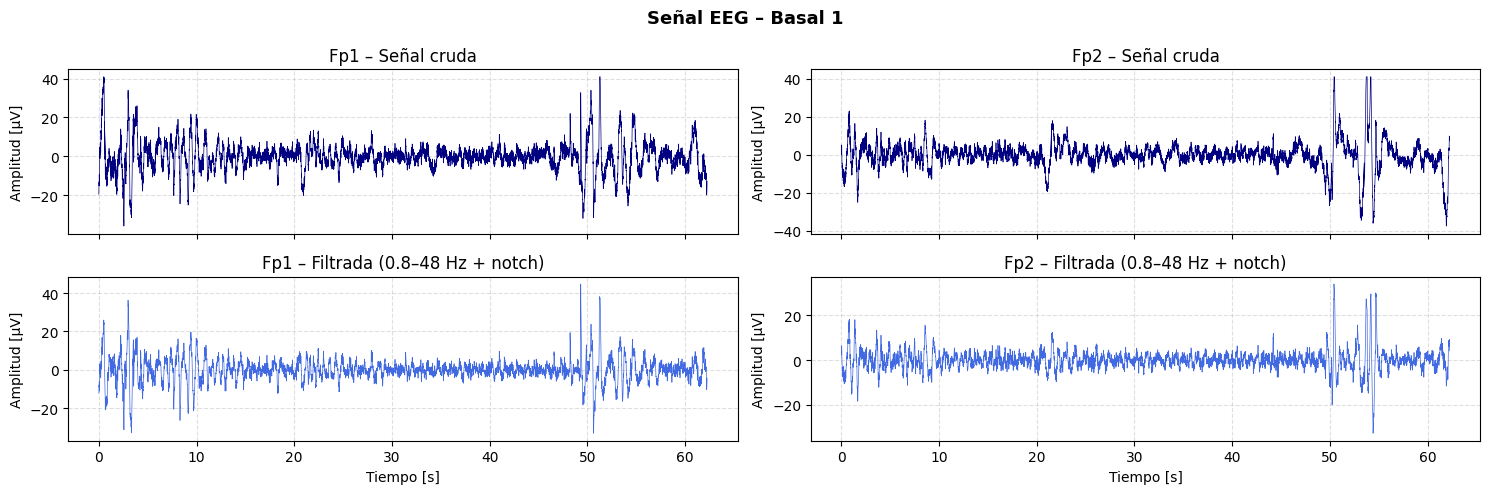

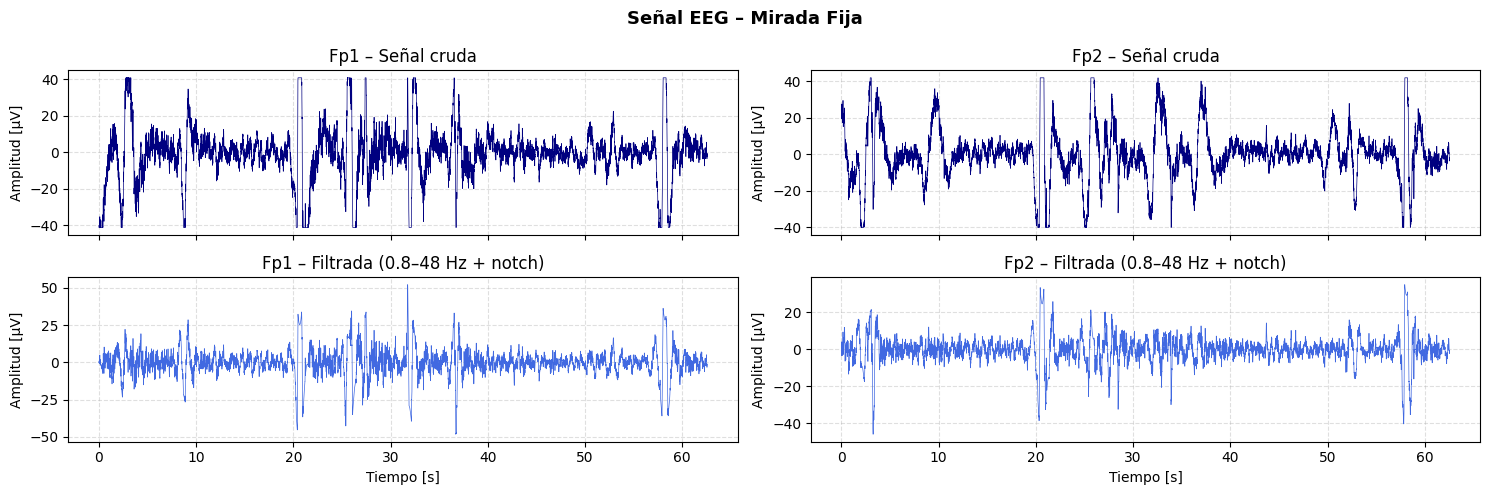

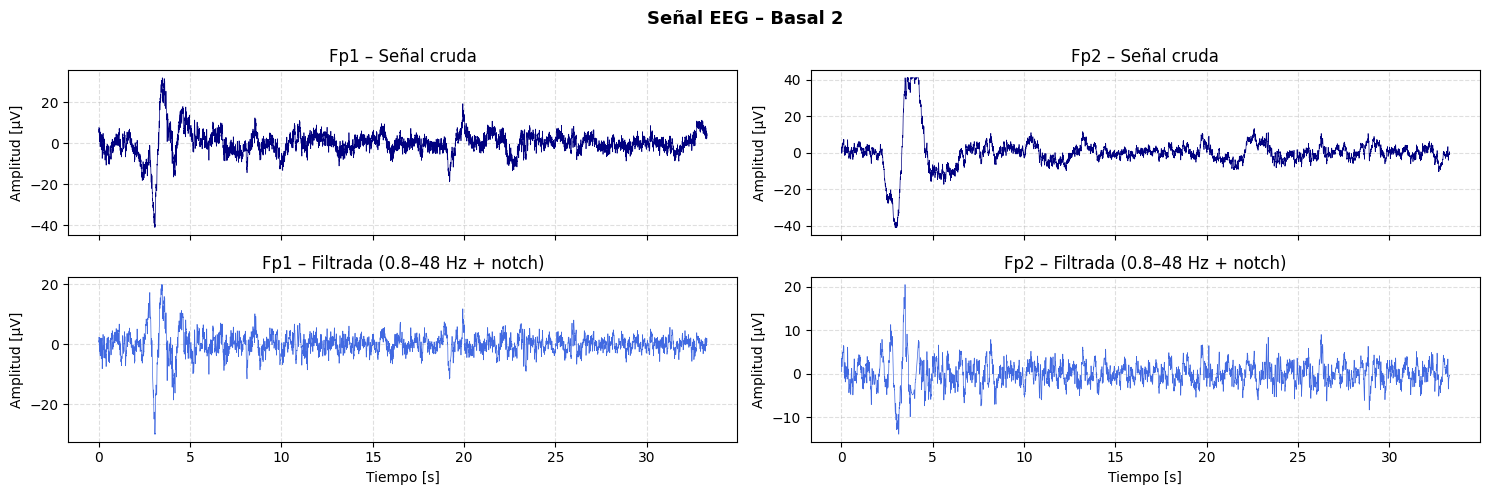

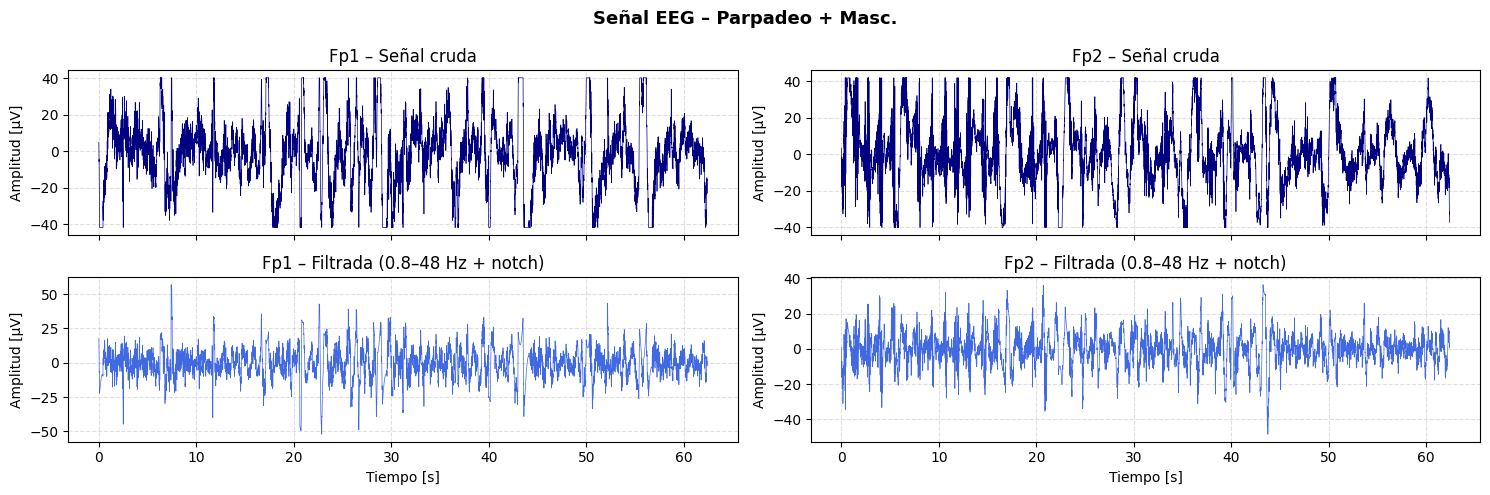

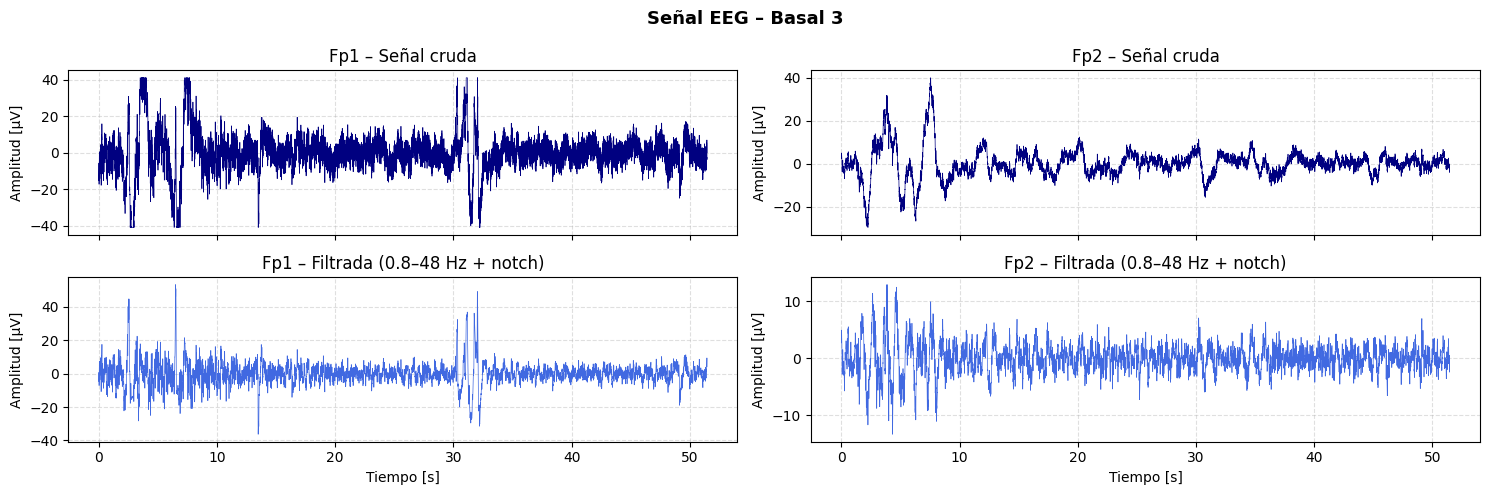

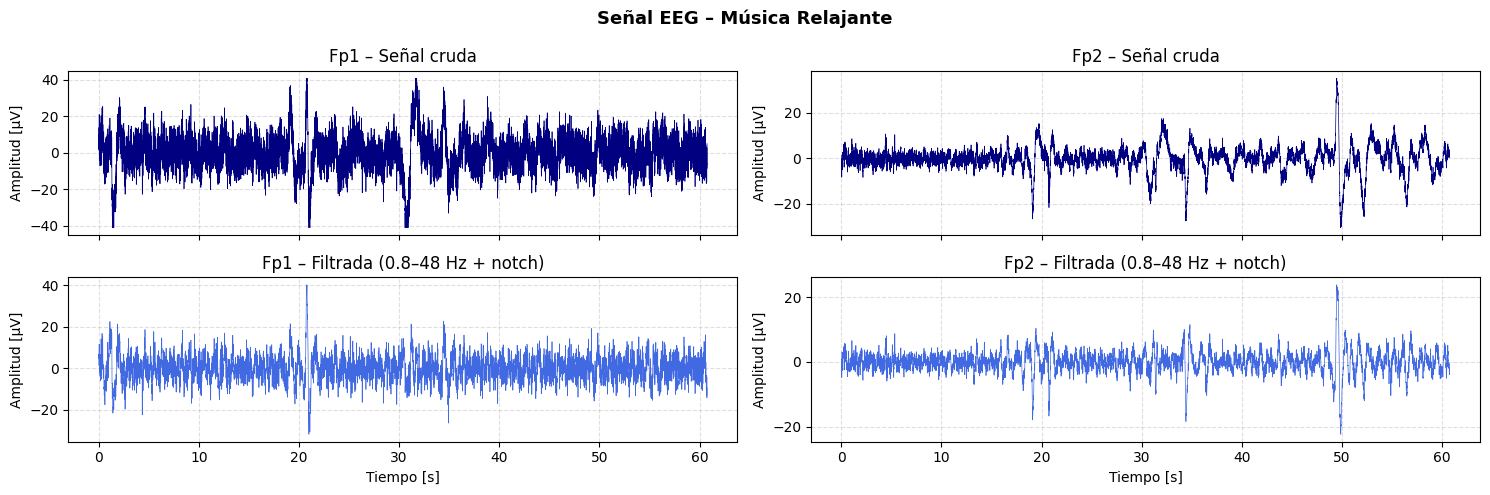

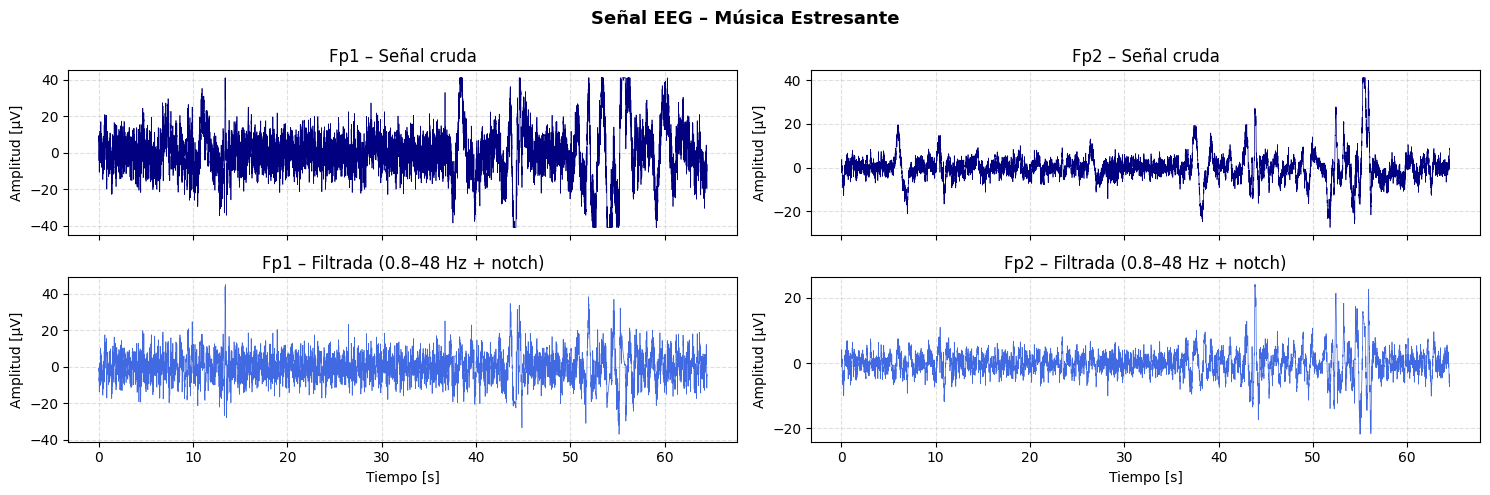

In [24]:
for nombre, d in datos.items():
    fig, axes = plt.subplots(2, 2, figsize=(15, 5), sharex="col")
    fig.suptitle(f"Señal EEG – {d['label']}", fontsize=13, fontweight="bold")

    for col_i, canal in enumerate(["Fp1", "Fp2"]):
        axes[0, col_i].plot(d[canal]["t"], d[canal]["raw"],
                            lw=0.5, color="navy")
        axes[0, col_i].set_title(f"{canal} – Señal cruda")
        axes[0, col_i].set_ylabel("Amplitud [µV]")
        axes[0, col_i].grid(True, ls="--", alpha=0.4)

        axes[1, col_i].plot(d[canal]["t"], d[canal]["filt"],
                            lw=0.5, color="royalblue")
        axes[1, col_i].set_title(f"{canal} – Filtrada (0.8–48 Hz + notch)")
        axes[1, col_i].set_ylabel("Amplitud [µV]")
        axes[1, col_i].set_xlabel("Tiempo [s]")
        axes[1, col_i].grid(True, ls="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

PSD Welch

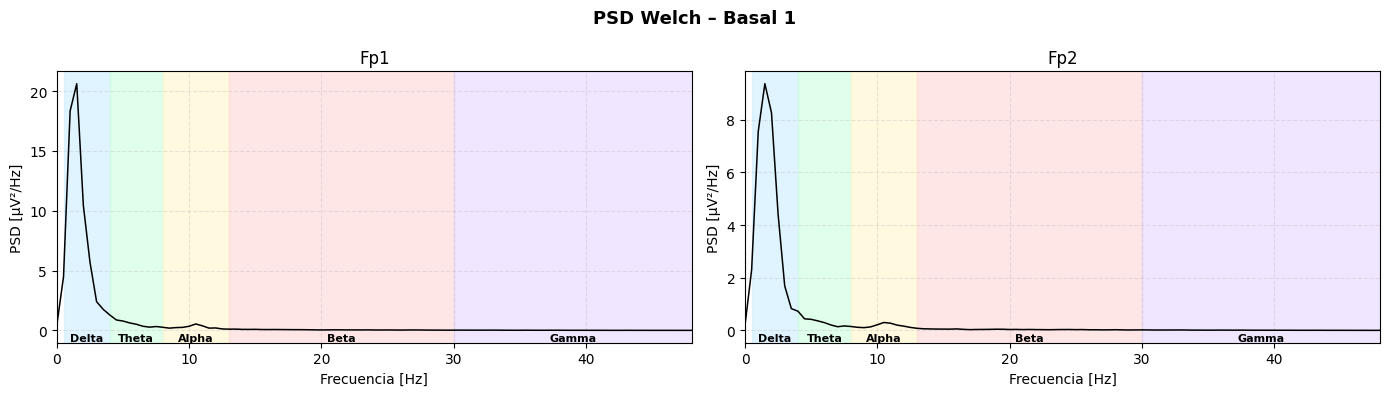

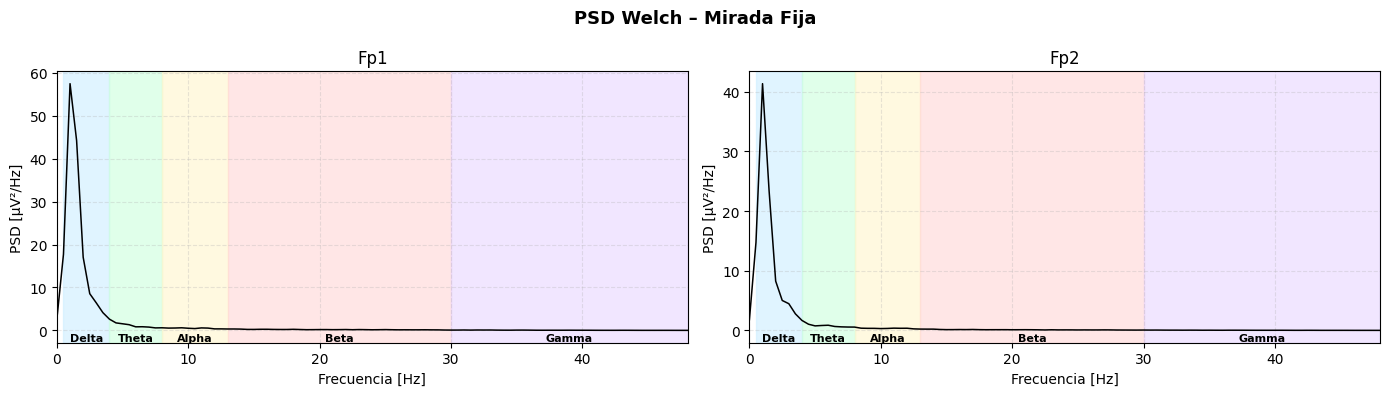

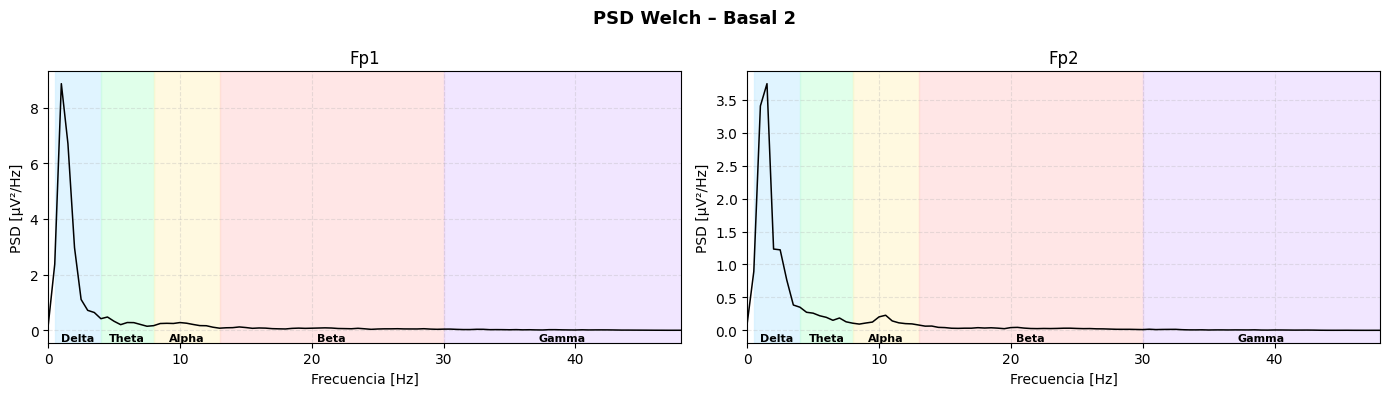

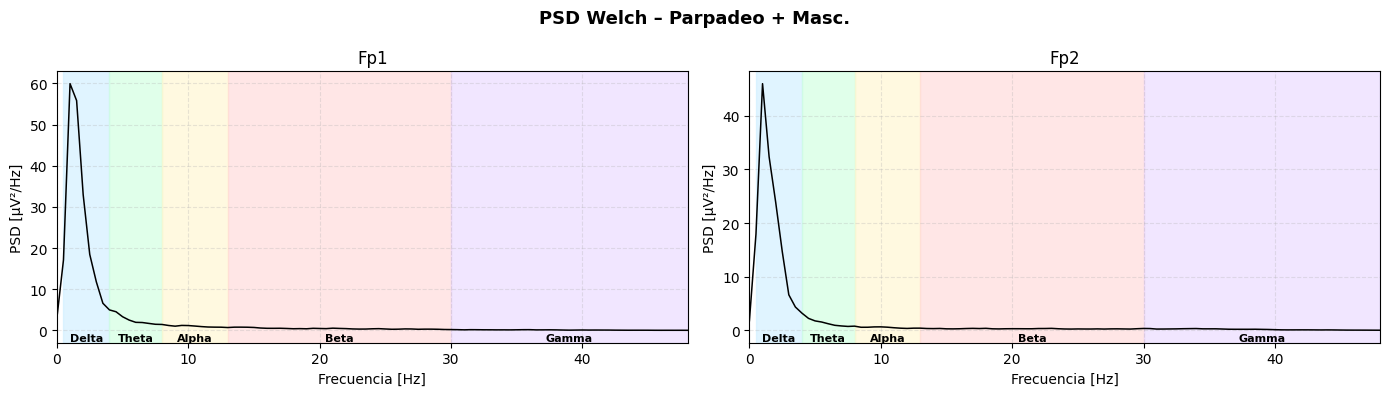

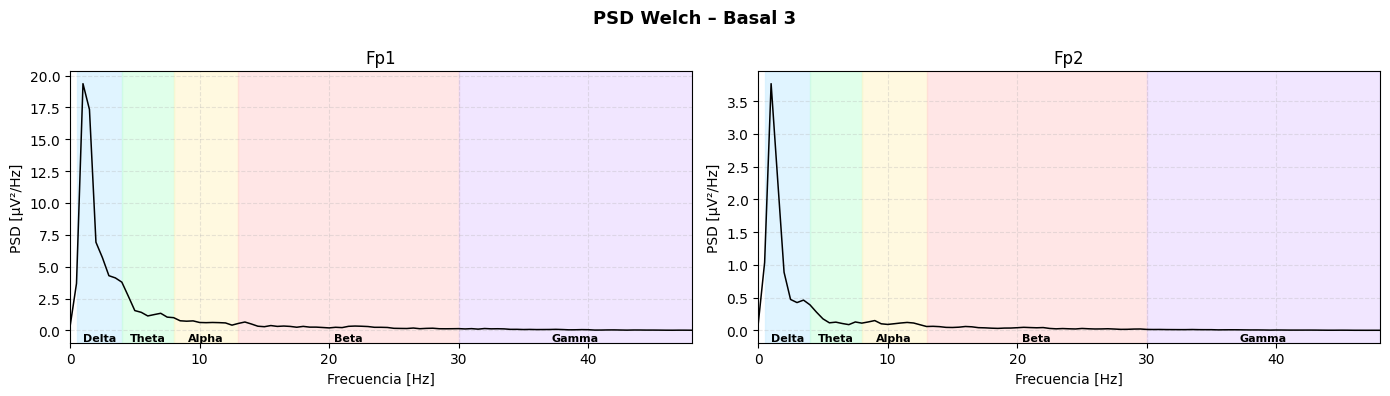

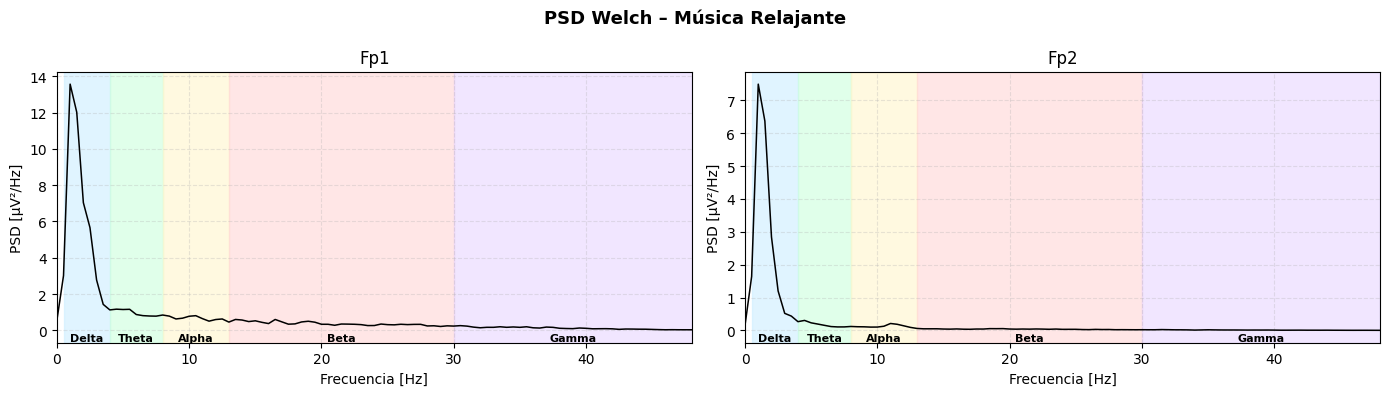

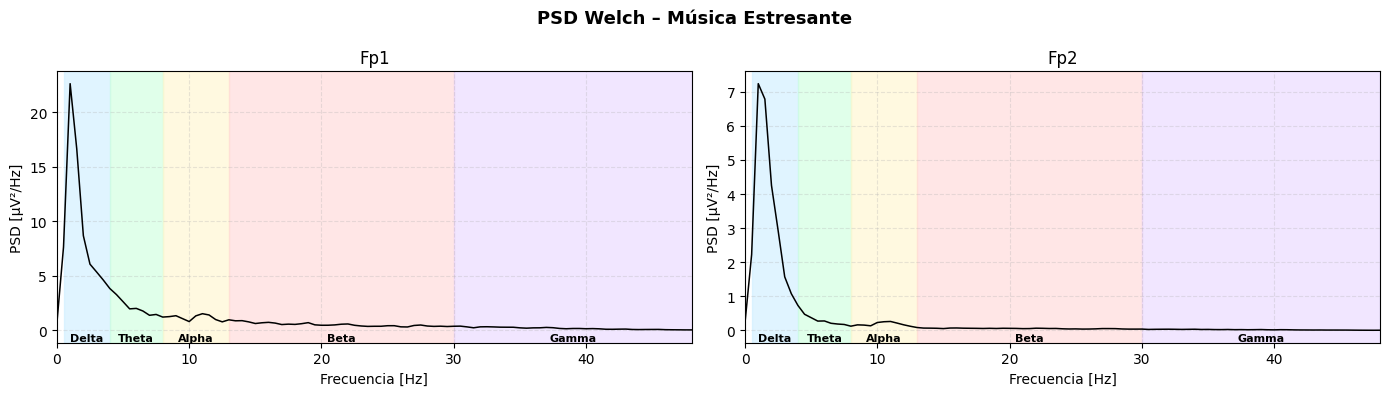


Potencia relativa por banda (%) – Fp1:

                   Delta  Theta  Alpha  Beta  Gamma
Basal 1             87.2    6.3    3.7   2.3    0.5
Mirada Fija         87.1    5.4    2.9   3.7    0.9
Basal 2             75.3    7.5    7.0   7.8    2.4
Parpadeo + Masc.    80.1    8.4    4.1   6.1    1.4
Basal 3             67.0   13.9    7.0   9.7    2.4
Música Relajante    58.6   10.2    8.8  16.7    5.8
Música Estresante   56.7   13.9    9.5  14.6    5.4

Potencia relativa por banda (%) – Fp2:

                   Delta  Theta  Alpha  Beta  Gamma
Basal 1             85.6    6.3    4.4   3.0    0.7
Mirada Fija         86.7    5.9    3.2   3.4    0.8
Basal 2             72.4   10.6    8.4   7.1    1.5
Parpadeo + Masc.    80.5    6.6    3.1   6.1    3.7
Basal 3             70.5    9.9    8.5   9.2    1.9
Música Relajante    82.0    5.8    5.3   5.3    1.7
Música Estresante   79.0    7.5    5.6   5.8    2.2


In [25]:
for nombre, d in datos.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"PSD Welch – {d['label']}", fontsize=13, fontweight="bold")

    for ax, canal in zip(axes, ["Fp1", "Fp2"]):
        for bname, (lo, hi) in BANDS.items():
            ax.axvspan(lo, hi, color=BAND_COLORS[bname], alpha=0.6, zorder=0)
            ax.text((lo + hi) / 2, 0, bname,
                    ha="center", va="bottom", fontsize=8, fontweight="bold",
                    transform=ax.get_xaxis_transform())
        ax.plot(d[canal]["freqs"], d[canal]["psd"], color="black", lw=1.1)
        ax.set_xlim(0, 48)
        ax.set_xlabel("Frecuencia [Hz]")
        ax.set_ylabel("PSD [µV²/Hz]")
        ax.set_title(canal)
        ax.grid(True, ls="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

# Tabla de potencias relativas
for canal_nombre in ["Fp1", "Fp2"]:
    print(f"\nPotencia relativa por banda (%) – {canal_nombre}:\n")
    filas = {d["label"]: {b: round(d[canal_nombre]["rel"][b] * 100, 1)
                          for b in BANDS}
             for d in datos.values()}
    print(pd.DataFrame(filas).T.to_string())


Comparación de potencia alpha: Ojos Cerrados vs Abiertos


  ANÁLISIS α – Basal 1 (ojos cerrados) vs Mirada Fija (ojos abiertos)


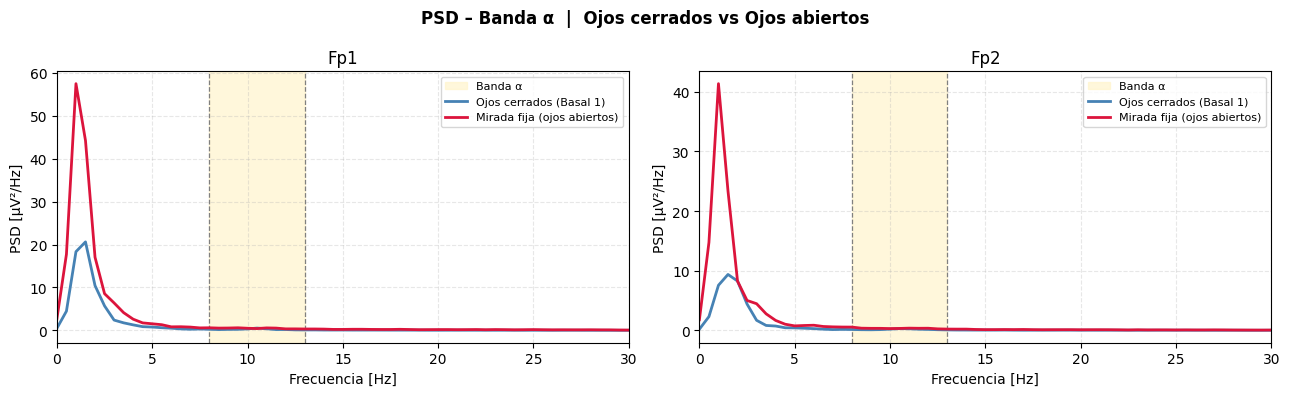


  Fp1:
    α ojos cerrados : 11.97% ± 10.85%
    α ojos abiertos : 9.39% ± 5.78%
    t-test pareado  : t=0.592, p=0.5601  (p≥0.05)

  Fp2:
    α ojos cerrados : 12.22% ± 8.83%
    α ojos abiertos : 11.96% ± 8.17%
    t-test pareado  : t=0.155, p=0.8781  (p≥0.05)


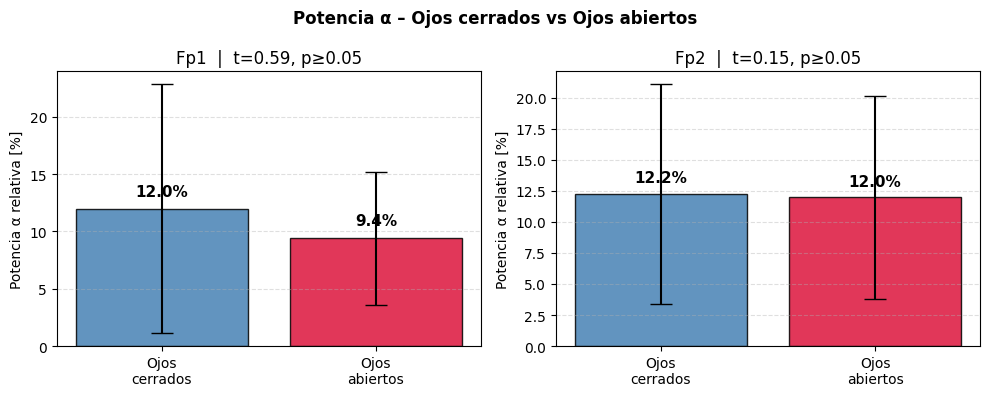

In [26]:
print("\n" + "="*62)
print("  ANÁLISIS α – Basal 1 (ojos cerrados) vs Mirada Fija (ojos abiertos)")
print("="*62)

c_cerr = "1_Primer_Ritmo_Basal"
c_abie = "2_Mirada-Fija-En-Un-Punto"

if c_cerr in datos and c_abie in datos:

    # PSD comparativa
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle("PSD – Banda α  |  Ojos cerrados vs Ojos abiertos",
                 fontsize=12, fontweight="bold")
    for ax, canal in zip(axes, ["Fp1", "Fp2"]):
        ax.axvspan(8, 13, color=BAND_COLORS["Alpha"], alpha=0.7, label="Banda α")
        ax.axvline(8,  color="gray", ls="--", lw=0.9)
        ax.axvline(13, color="gray", ls="--", lw=0.9)
        ax.plot(datos[c_cerr][canal]["freqs"], datos[c_cerr][canal]["psd"],
                color="steelblue", lw=2, label="Ojos cerrados (Basal 1)")
        ax.plot(datos[c_abie][canal]["freqs"], datos[c_abie][canal]["psd"],
                color="crimson",   lw=2, label="Mirada fija (ojos abiertos)")
        ax.set_xlim(0, 30)
        ax.set_xlabel("Frecuencia [Hz]")
        ax.set_ylabel("PSD [µV²/Hz]")
        ax.set_title(canal)
        ax.legend(fontsize=8)
        ax.grid(True, ls="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # t-test + barras
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle("Potencia α – Ojos cerrados vs Ojos abiertos", fontweight="bold")

    for ax, canal in zip(axes, ["Fp1", "Fp2"]):
        ep_c = epoch_banda(datos[c_cerr][canal]["filt"], "Alpha")
        ep_a = epoch_banda(datos[c_abie][canal]["filt"], "Alpha")
        n    = min(len(ep_c), len(ep_a))
        tst, p = ttest_rel(ep_c[:n], ep_a[:n])
        sig_str = "p<0.05" if p < 0.05 else "p≥0.05"

        print(f"\n  {canal}:")
        print(f"    α ojos cerrados : {ep_c.mean()*100:.2f}% ± {ep_c.std()*100:.2f}%")
        print(f"    α ojos abiertos : {ep_a.mean()*100:.2f}% ± {ep_a.std()*100:.2f}%")
        print(f"    t-test pareado  : t={tst:.3f}, p={p:.4f}  ({sig_str})")

        medias = [ep_c.mean()*100, ep_a.mean()*100]
        stds   = [ep_c.std()*100,  ep_a.std()*100]
        bars   = ax.bar(["Ojos\ncerrados", "Ojos\nabiertos"], medias,
                        yerr=stds, capsize=8,
                        color=["steelblue", "crimson"],
                        alpha=0.85, edgecolor="black")
        for bar, val in zip(bars, medias):
            ax.text(bar.get_x() + bar.get_width()/2,
                    val + max(stds) * 0.08,
                    f"{val:.1f}%", ha="center", va="bottom",
                    fontsize=11, fontweight="bold")
        ax.set_ylabel("Potencia α relativa [%]")
        ax.set_title(f"{canal}  |  t={tst:.2f}, {sig_str}")
        ax.grid(axis="y", ls="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

Incremento betha: Basal vs Mirada fija


  ANÁLISIS β – Basal 1 vs Mirada Fija (t-test pareado)

  Fp1:
    β Basal 1     : 7.40% ± 5.39%
    β Mirada Fija : 14.25% ± 7.81%
    t-test pareado: t=-2.777, p=0.0113  (p<0.05)

  Fp2:
    β Basal 1     : 8.38% ± 3.81%
    β Mirada Fija : 13.55% ± 7.59%
    t-test pareado: t=-2.659, p=0.0135  (p<0.05)


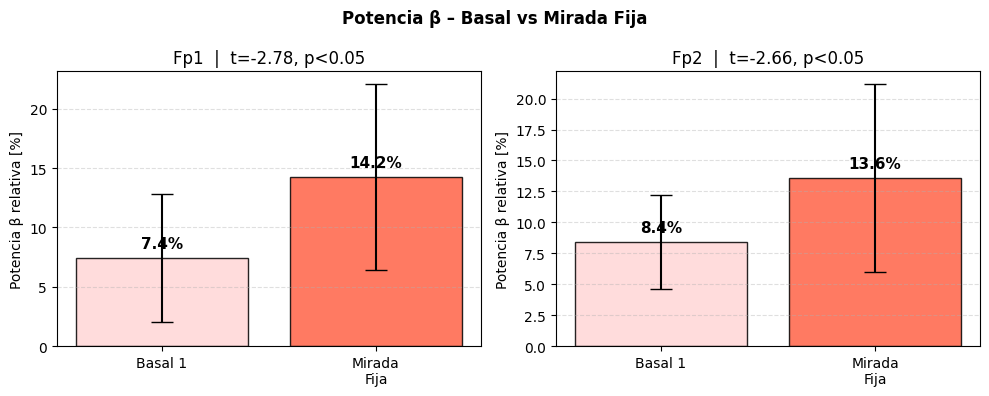

In [27]:
print("\n" + "="*62)
print("  ANÁLISIS β – Basal 1 vs Mirada Fija (t-test pareado)")
print("="*62)

c_bas  = "1_Primer_Ritmo_Basal"
c_acti = "2_Mirada-Fija-En-Un-Punto"

if c_bas in datos and c_acti in datos:

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle("Potencia β – Basal vs Mirada Fija", fontweight="bold")

    for ax, canal in zip(axes, ["Fp1", "Fp2"]):
        ep_b = epoch_banda(datos[c_bas ][canal]["filt"], "Beta")
        ep_a = epoch_banda(datos[c_acti][canal]["filt"], "Beta")
        n    = min(len(ep_b), len(ep_a))
        tst, p = ttest_rel(ep_b[:n], ep_a[:n])
        sig_str = "p<0.05" if p < 0.05 else "p≥0.05"

        print(f"\n  {canal}:")
        print(f"    β Basal 1     : {ep_b.mean()*100:.2f}% ± {ep_b.std()*100:.2f}%")
        print(f"    β Mirada Fija : {ep_a.mean()*100:.2f}% ± {ep_a.std()*100:.2f}%")
        print(f"    t-test pareado: t={tst:.3f}, p={p:.4f}  ({sig_str})")

        medias = [ep_b.mean()*100, ep_a.mean()*100]
        stds   = [ep_b.std()*100,  ep_a.std()*100]
        bars   = ax.bar(["Basal 1", "Mirada\nFija"], medias,
                        yerr=stds, capsize=8,
                        color=[BAND_COLORS["Beta"], "tomato"],
                        alpha=0.85, edgecolor="black")
        for bar, val in zip(bars, medias):
            ax.text(bar.get_x() + bar.get_width()/2,
                    val + max(stds) * 0.08,
                    f"{val:.1f}%", ha="center", va="bottom",
                    fontsize=11, fontweight="bold")
        ax.set_ylabel("Potencia β relativa [%]")
        ax.set_title(f"{canal}  |  t={tst:.2f}, {sig_str}")
        ax.grid(axis="y", ls="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


Detección de parpadeos


  DETECCIÓN DE PARPADEOS – Parpadeo + Masticación Constante

  Fp1:
    Umbral (3×std)       : ±33.8 µV
    Parpadeos detectados : 12

  Fp2:
    Umbral (3×std)       : ±28.3 µV
    Parpadeos detectados : 15


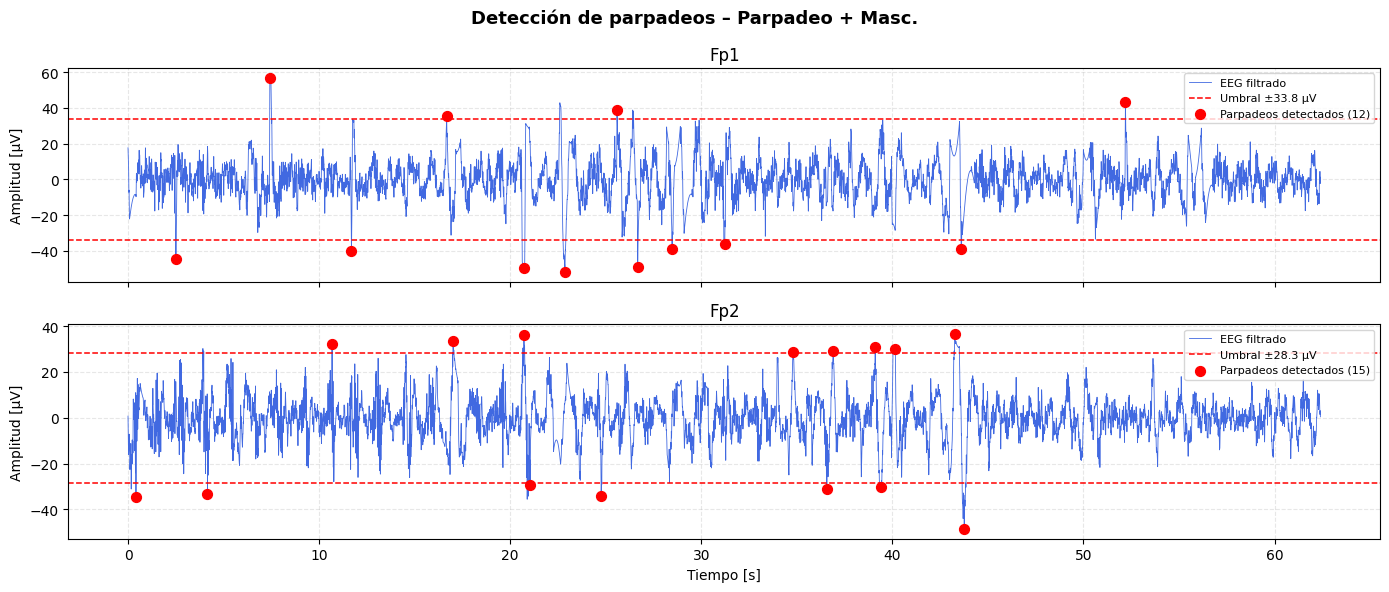


Procesamiento completo.


In [28]:
print("\n" + "="*62)
print("  DETECCIÓN DE PARPADEOS – Parpadeo + Masticación Constante")
print("="*62)

clave_art = "4_Parpadeo_Y_Masticación_Constante"
if clave_art in datos:
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(f"Detección de parpadeos – {datos[clave_art]['label']}",
                 fontsize=13, fontweight="bold")

    for ax_i, canal in enumerate(["Fp1", "Fp2"]):
        sig = datos[clave_art][canal]["filt"]
        t   = datos[clave_art][canal]["t"]

        peaks, heights, umbral = detectar_parpadeos(sig)

        print(f"\n  {canal}:")
        print(f"    Umbral (3×std)       : ±{umbral:.1f} µV")
        print(f"    Parpadeos detectados : {len(peaks)}")

        axes[ax_i].plot(t, sig, lw=0.6, color="royalblue", label="EEG filtrado")
        axes[ax_i].axhline( umbral, color="red", ls="--", lw=1.1,
                            label=f"Umbral ±{umbral:.1f} µV")
        axes[ax_i].axhline(-umbral, color="red", ls="--", lw=1.1)
        if len(peaks):
            axes[ax_i].scatter(t[peaks], sig[peaks],
                               color="red", s=50, zorder=5,
                               label=f"Parpadeos detectados ({len(peaks)})")
        axes[ax_i].set_ylabel("Amplitud [µV]")
        axes[ax_i].set_title(canal)
        axes[ax_i].legend(fontsize=8, loc="upper right")
        axes[ax_i].grid(True, ls="--", alpha=0.3)

    axes[-1].set_xlabel("Tiempo [s]")
    plt.tight_layout()
    plt.show()

print("\nProcesamiento completo.")